In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [70]:
df=pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [71]:
X=df['area'].to_numpy()
Y=df['price'].to_numpy()

print(type(X))

<class 'numpy.ndarray'>


In [72]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X=scaler_X.fit_transform(X.reshape(-1,1)).flatten()
y=scaler_y.fit_transform(Y.reshape(-1,1)).flatten()

print(X.shape)


(545,)


In [73]:
# MSE cost func

def compute_cost(X,y,w,b):
  m=len(X)
  cost=0.0

  for i in range(m):
    y_pred=w*X[i]+b
    cost+=(y_pred-y[i])**2

  cost=cost/(2*m)
  return cost


0.5000000000000009


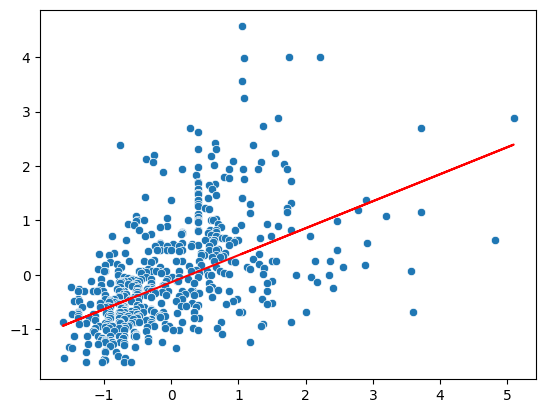

0.5000000000000009


In [74]:
cost=compute_cost(X,y,w=0,b=0)

sns.scatterplot(x=X,y=y)
plt.plot(X,w*X+b,c='r')
print(cost)
plt.show()
print(cost)

0.46400265422191916


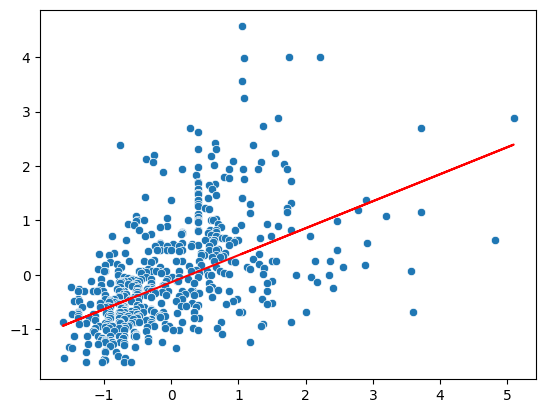

0.46400265422191916


In [75]:
cost=compute_cost(X,y,w=1,b=0)

sns.scatterplot(x=X,y=y)
plt.plot(X,w*X+b,c='r')
print(cost)
plt.show()
print(cost)

In [76]:
np.random.seed(42)
w = np.random.randn()
b = np.random.randn()
initial_cost = compute_cost(X, y, w, b)
print(f"Initial slope:     {w:.4f}")
print(f"Initial intercept: {b:.4f}")
print(f"Initial cost:      {initial_cost:.4f}")


Initial slope:     0.4967
Initial intercept: -0.1383
Initial cost:      0.3667


In [77]:
# gradiant descent from scratch
def compute_gradient(X,y,w,b):
  m=len(X)
  dw=0
  db=0

  for i in range(m):
    y_pred=w*X[i]+b
    error=y_pred-y[i]

    dw=dw+error*X[i]
    db=db+error

  dw=dw/m
  db=db/m

  return dw,db



In [78]:
def gradient_descent(X,y,w,b,alpha,iterations):
  cost_list=[]
  iteration_list=[]
  for i in range(iterations):
    dw,db=compute_gradient(X,y,w,b)

    w=w-alpha*dw
    b=b-alpha*db

    cost=compute_cost(X,y,w,b)
    cost_list.append(cost)
    iteration_list.append(i)

    if i%100==0:
      print(f"Iteration {i:4}: Cost {float(cost):8.2f}")

  return w,b,cost_list,iteration_list

In [79]:
w_final, b_final, cost_history,iteration_list = gradient_descent(X, y, w=0, b=0, alpha=0.01, iterations=1000)

print("Final w:", w_final)
print("Final b:", b_final)

print(f"Final cost: {cost_history[-1]:0.2f}")
print(f"Final cost: {compute_cost(X,y,w_final,b_final):0.2f}")

Iteration    0: Cost     0.50
Iteration  100: Cost     0.38
Iteration  200: Cost     0.36
Iteration  300: Cost     0.36
Iteration  400: Cost     0.36
Iteration  500: Cost     0.36
Iteration  600: Cost     0.36
Iteration  700: Cost     0.36
Iteration  800: Cost     0.36
Iteration  900: Cost     0.36
Final w: 0.5359742061040541
Final b: 2.546138631226592e-16
Final cost: 0.36
Final cost: 0.36


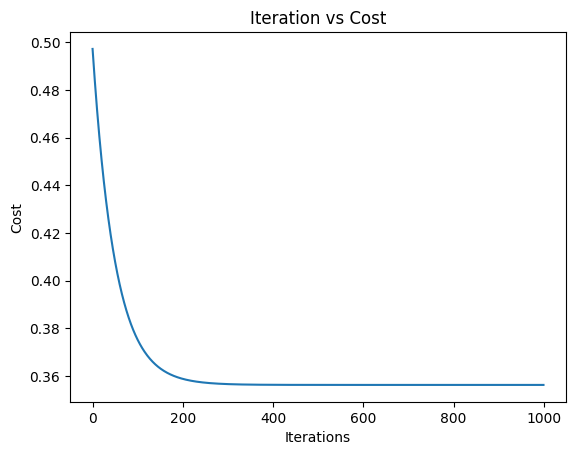

In [80]:
plt.plot(cost_history)
plt.title("Iteration vs Cost")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

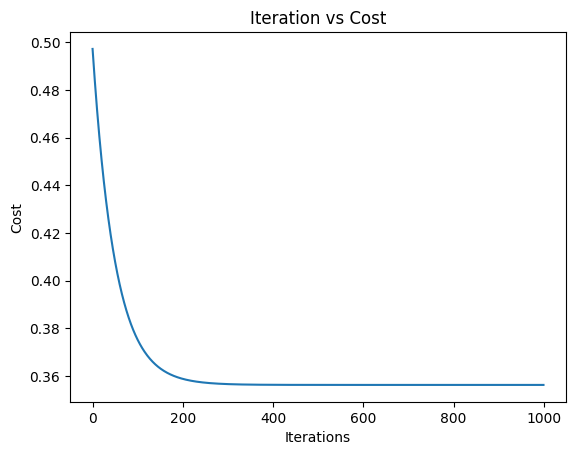

In [81]:
plt.plot(iteration_list,cost_history)
plt.title("Iteration vs Cost")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

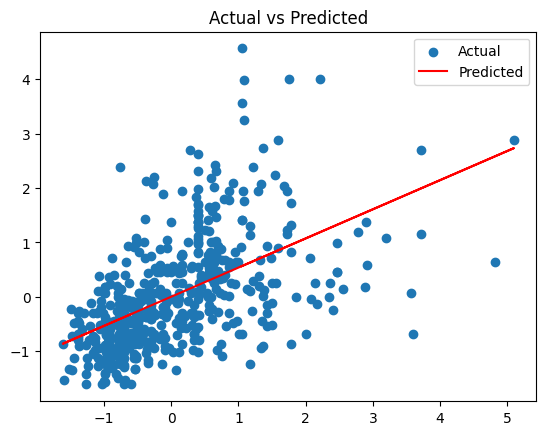

In [82]:
y_pred = w_final * X + b_final

plt.scatter(X, y, label="Actual")
plt.plot(X, y_pred, color="red", label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [83]:
print("Final w:", w_final)
print("Final b:", b_final)
print(f"Final cost: {compute_cost(X,y,w_final,b_final):0.2f}")

Final w: 0.5359742061040541
Final b: 2.546138631226592e-16
Final cost: 0.36


In [84]:
def predict_price(x):
    # scale input
    x_scaled = scaler_X.transform([[x]]).flatten()[0]

    # correct prediction (USE x_scaled, not X)
    y_pred = w_final * x_scaled + b_final

    # convert back to original scale
    y_original = scaler_y.inverse_transform([[y_pred]])[0][0]

    return y_original

In [85]:
test_area = 2400

predicted_price = predict_price(test_area)

print("Predicted price:", predicted_price)

Predicted price: 3496103.085535764


In [86]:
test_area = 7420

pred = predict_price(test_area)

actual = df[df["area"] == 7420]["price"].values[0]

print("Predicted:", pred)
print("Actual:", actual)
print("Difference:", abs(pred - actual))

Predicted: 5815116.935742198
Actual: 13300000
Difference: 7484883.064257802


In [87]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
